In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

set this once so every chart and table looks clean.

In [3]:
df = pd.read_csv(r"F:\data analyst\Project 1\restaurants_clean.csv")
cuisines = pd.read_csv(r"F:\data analyst\Project 1\restaurant_cuisines.csv")

df.head()

,id,name,city,area,locality,address,avg_rating,has_rating,cost_for_two,ratings_count_min,cuisines_raw,has_cuisine_data,delivery_time,veg,type,rating_tier,cost_tier,delivery_speed,ratings_bucket,primary_cuisine,cuisine_count
0,328315,HIIT Meals,Ahmedabad,Vishala,Vasna,C11 Rajyash Rise Near Vishala Restaurant Vasna...,NaN,f,150,NaN,['Fast Food' 'Combo' 'Snacks' 'North Indian' '...,t,51,f,F,Unrated,Budget,Slow,Insufficient,Fast Food,7
1,108879,Jay Jalaram Parotha House,Ahmedabad,Ellisbridge,Ashram Road,Capital Commercial Centre Near UCO Bank Ashram...,3.9,t,250,100.0,['North Indian'],t,29,t,F,Average,Affordable,Fast,100-500,North Indian,1
2,140314,Jalaram Parotha House,Ahmedabad,Paldi,Paldi,1214 Sahjanand Trade Centre Opposite Kothawala...,3.9,t,450,20.0,['North Indian' 'Gujarati'],t,28,t,F,Average,Mid-range,Fast,Under 50,North Indian,2
3,270210,Cake Dengo Cake Shop,Ahmedabad,Drive In Road,Gurukul rod,Unit No 11-12 Gokul Complex Opp Gurukul Mandir...,4.1,t,500,100.0,['Desserts'],t,50,f,F,Good,Mid-range,Slow,100-500,Desserts,1
4,47788,The Westend Hotel (Mayflower),Ahmedabad,Ellisbridge,Ellisbridge,Hotel The Westend Gujarat College Road Ellis B...,4.4,t,450,100.0,['Indian' 'Chinese'],t,27,f,F,Excellent,Mid-range,Fast,100-500,Indian,2


In [4]:
print(df.shape)            # expect (8691, N)

(8691, 21)


In [5]:
df.info()                  # dtypes + non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 8691 entries, 0 to 8690
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8691 non-null   int64  
 1   name               8691 non-null   str    
 2   city               8691 non-null   str    
 3   area               8691 non-null   str    
 4   locality           8681 non-null   str    
 5   address            8682 non-null   str    
 6   avg_rating         5412 non-null   float64
 7   has_rating         8691 non-null   str    
 8   cost_for_two       8691 non-null   int64  
 9   ratings_count_min  5412 non-null   float64
 10  cuisines_raw       8691 non-null   str    
 11  has_cuisine_data   8691 non-null   str    
 12  delivery_time      8691 non-null   int64  
 13  veg                8685 non-null   str    
 14  type               8691 non-null   str    
 15  rating_tier        8691 non-null   str    
 16  cost_tier          8691 non-null   

In [6]:
df.describe()              # numeric summary: min/max/mean for rating, cost, delivery

,id,avg_rating,cost_for_two,ratings_count_min,delivery_time,cuisine_count
count,8691.000000,5412.000000,8691.000000,5412.000000,8691.000000,8691.000000
mean,244855.957887,4.112398,348.492463,202.958241,53.959268,2.721436
std,158650.520513,0.345170,231.213867,490.010794,14.290555,2.110705
min,211.000000,2.000000,0.000000,20.000000,20.000000,1.000000
25%,72885.500000,3.900000,200.000000,20.000000,44.000000,1.000000
50%,283560.000000,4.200000,300.000000,100.000000,52.000000,2.000000
75%,393448.500000,4.300000,400.000000,100.000000,64.000000,3.000000
max,466928.000000,5.000000,2500.000000,10000.000000,109.000000,23.000000


In [7]:
df.isnull().sum()          # NULL pattern

id                      0
name                    0
city                    0
area                    0
locality               10
address                 9
avg_rating           3279
has_rating              0
cost_for_two            0
ratings_count_min    3279
cuisines_raw            0
has_cuisine_data        0
delivery_time           0
veg                     6
type                    0
rating_tier             0
cost_tier               0
delivery_speed          0
ratings_bucket          0
primary_cuisine         0
cuisine_count           0
dtype: int64

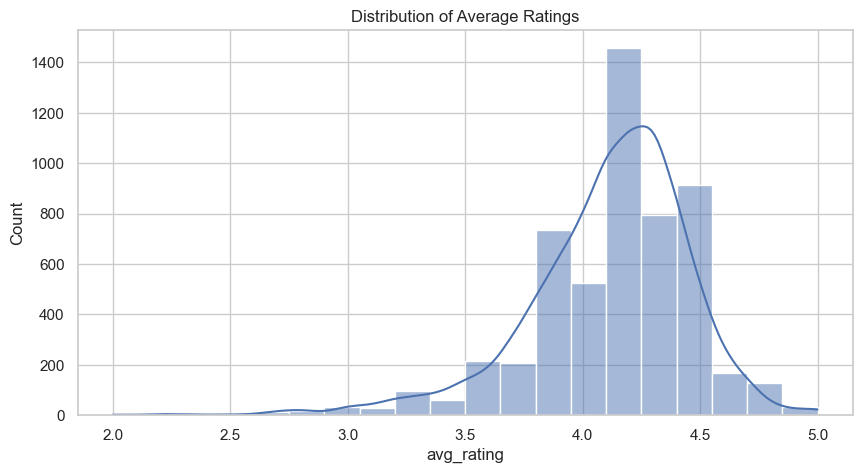

In [8]:
# Rating distribution
sns.histplot(df["avg_rating"].dropna(), bins=20, kde=True)
plt.title("Distribution of Average Ratings")
plt.show()

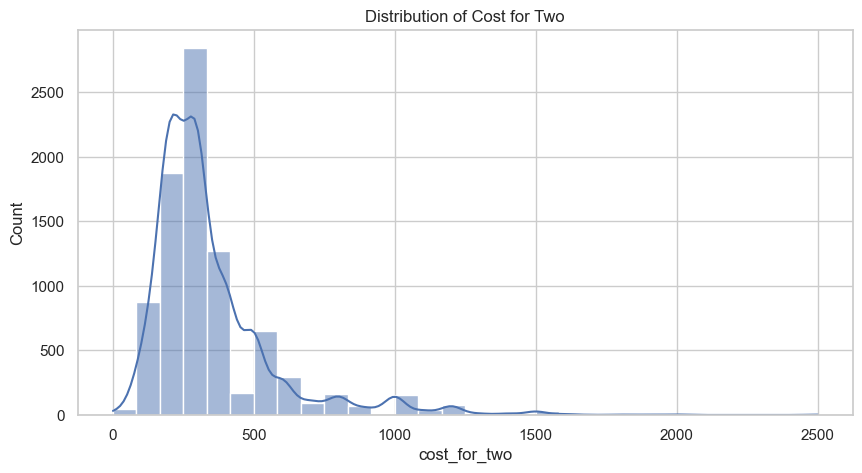

In [9]:
# Cost distribution
sns.histplot(df["cost_for_two"].dropna(), bins=30, kde=True)
plt.title("Distribution of Cost for Two")
plt.show()

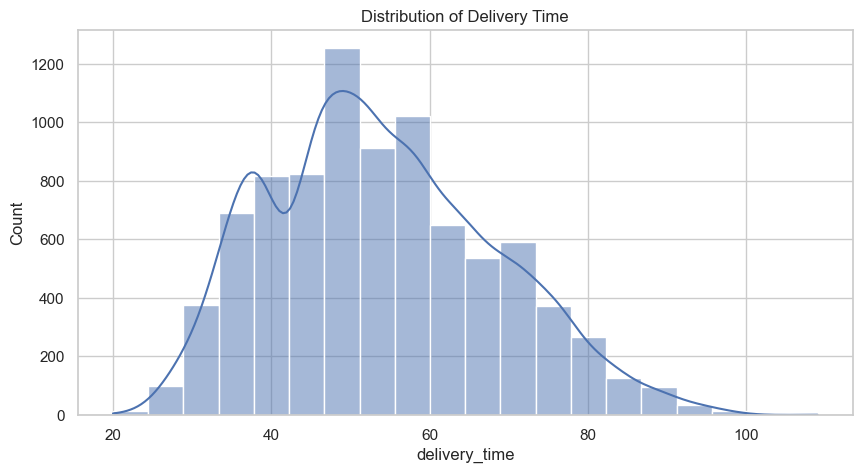

In [10]:
# Delivery time distribution
sns.histplot(df["delivery_time"].dropna(), bins=20, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

 ### Categorical breakdowns

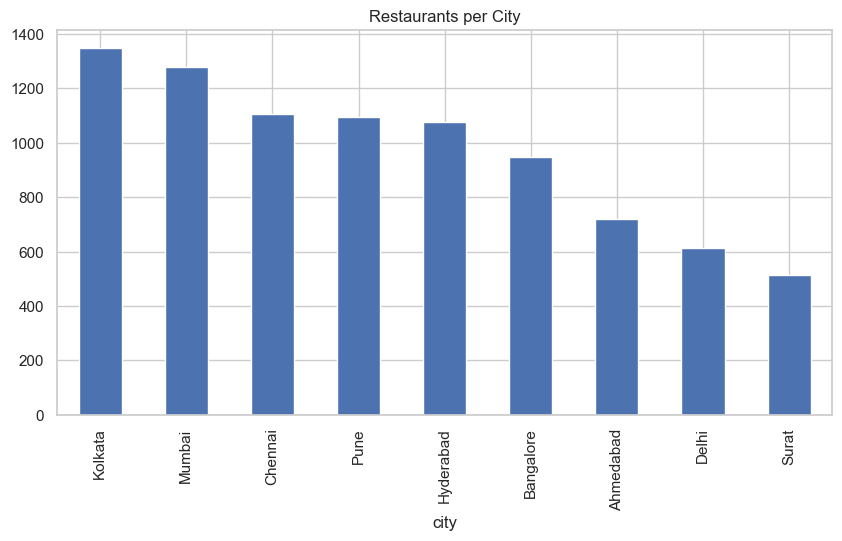

In [11]:
# Restaurants per city (market density)
df["city"].value_counts().plot(kind="bar", title="Restaurants per City")
plt.show()

In [12]:
# Tier distributions
for col in ["rating_tier", "cost_tier", "delivery_speed"]:
    print(df[col].value_counts(), "\n")

rating_tier
Unrated      3279
Excellent    2030
Good         1980
Average      1154
Poor          248
Name: count, dtype: int64 

cost_tier
Affordable    5081
Mid-range     1950
Budget         983
Premium        525
Luxury         152
Name: count, dtype: int64 

delivery_speed
Slow         3439
Very Slow    2685
Average      2351
Fast          215
Very Fast       1
Name: count, dtype: int64 



 City-level comparison (the core of your strategy story)

In [13]:
city_summary = df.groupby("city").agg(
    restaurant_count=("id", "count"),
    avg_rating=("avg_rating", "mean"),
    avg_cost=("cost_for_two", "mean"),
    avg_delivery=("delivery_time", "mean")
).round(2).sort_values("restaurant_count", ascending=False)

city_summary

,restaurant_count,avg_rating,avg_cost,avg_delivery
city,,,,
Kolkata,1347,4.15,363.21,67.80
Mumbai,1278,4.12,393.80,48.32
Chennai,1107,4.17,356.24,58.95
Pune,1093,4.14,353.52,55.81
Hyderabad,1075,4.01,299.93,49.93
Bangalore,946,4.18,382.52,50.53
Ahmedabad,719,4.07,317.80,44.69
Delhi,613,4.02,333.03,50.79
Surat,513,4.08,270.04,48.48


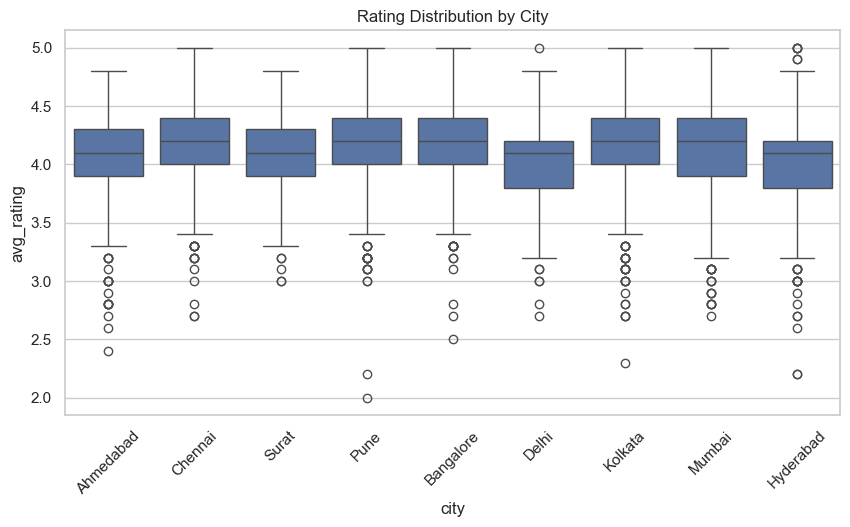

In [14]:
# Quality spread per city
sns.boxplot(data=df, x="city", y="avg_rating")
plt.xticks(rotation=45)
plt.title("Rating Distribution by City")
plt.show()

 Bivariate / statistical analysis

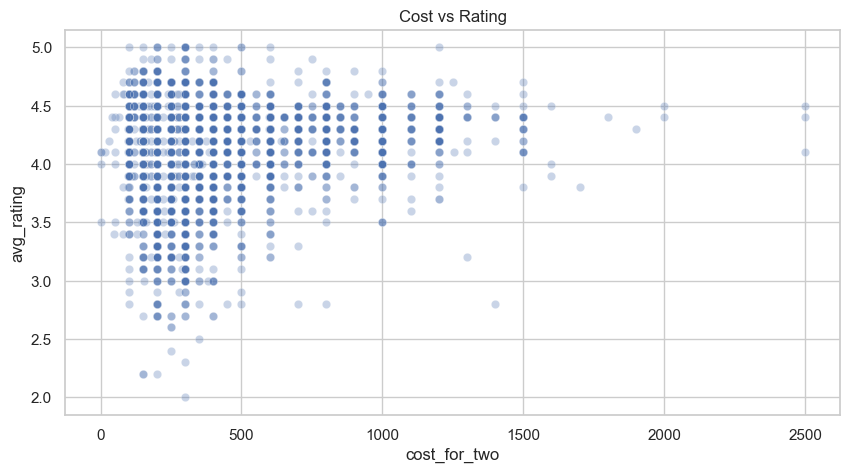

Cost-Rating correlation: r=0.137, p=0.0000


In [17]:
# Cost vs Rating — do pricier places rate higher?
valid = df.dropna(subset=["cost_for_two", "avg_rating"])
sns.scatterplot(data=valid, x="cost_for_two", y="avg_rating", alpha=0.3)
plt.title("Cost vs Rating")
plt.show()

r, p = stats.pearsonr(valid["cost_for_two"], valid["avg_rating"])
print(f"Cost-Rating correlation: r={r:.3f}, p={p:.4f}")

In [18]:
# Delivery time vs Rating — does speed affect satisfaction?
valid2 = df.dropna(subset=["delivery_time", "avg_rating"])
r, p = stats.pearsonr(valid2["delivery_time"], valid2["avg_rating"])
print(f"Delivery-Rating correlation: r={r:.3f}, p={p:.4f}")

Delivery-Rating correlation: r=-0.045, p=0.0010


In [19]:
# Veg vs Non-veg — is there a rating difference? (t-test)
veg = df[df["veg"] == True]["avg_rating"].dropna()
nonveg = df[df["veg"] == False]["avg_rating"].dropna()
t, p = stats.ttest_ind(veg, nonveg, equal_var=False)
print(f"Veg mean={veg.mean():.2f}, Non-veg mean={nonveg.mean():.2f}, p={p:.4f}")

Veg mean=nan, Non-veg mean=nan, p=nan


C:\Users\saimm\AppData\Local\Temp\ipykernel_15012\4156849419.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t, p = stats.ttest_ind(veg, nonveg, equal_var=False)


In [20]:
print(df["veg"].dtype)
print(df["veg"].value_counts(dropna=False))

str
veg
f      6408
t      2277
NaN       6
Name: count, dtype: int64


In [21]:
df["veg"] = df["veg"].map({"t": True, "f": False})

In [22]:
veg = df[df["veg"] == True]["avg_rating"].dropna()
nonveg = df[df["veg"] == False]["avg_rating"].dropna()
print(len(veg), len(nonveg))   # should print counts ≤ 2277 and ≤ 6408

t, p = stats.ttest_ind(veg, nonveg, equal_var=False)
print(f"Veg mean={veg.mean():.2f}, Non-veg mean={nonveg.mean():.2f}, p={p:.4f}")

1535 3875
Veg mean=4.16, Non-veg mean=4.09, p=0.0000


In [23]:
for col in ["has_rating", "has_cuisine_data"]:
    if df[col].dtype == "object":
        df[col] = df[col].map({"t": True, "f": False})

In [24]:
# Cohen's d — measures practical magnitude, not just significance
n1, n2 = len(veg), len(nonveg)
pooled_std = np.sqrt(((n1-1)*veg.std()**2 + (n2-1)*nonveg.std()**2) / (n1+n2-2))
d = (veg.mean() - nonveg.mean()) / pooled_std
print(f"Cohen's d = {d:.3f}")

Cohen's d = 0.196


 Cuisine analysis (using the bridge table)

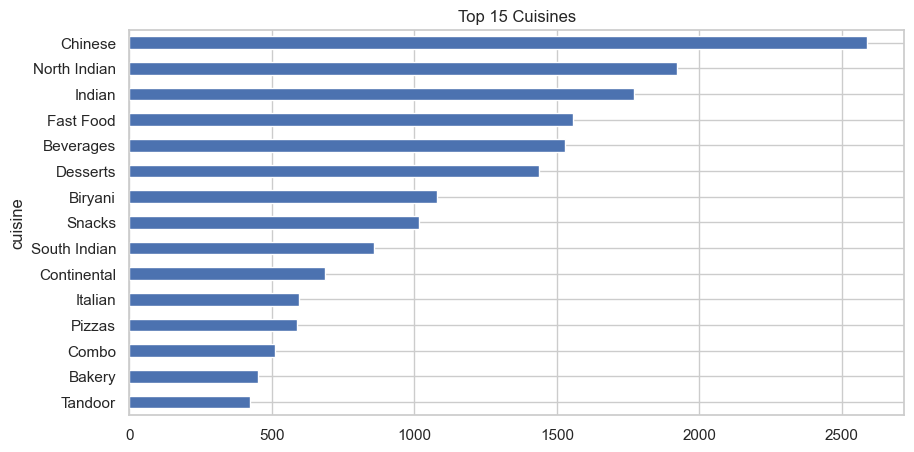

In [25]:
# Top 15 cuisines overall
top = cuisines["cuisine"].value_counts().head(15)
top.plot(kind="barh", title="Top 15 Cuisines")
plt.gca().invert_yaxis()
plt.show()

In [26]:
# Which cuisines command a price premium?
merged = cuisines.merge(df[["id", "cost_for_two"]],
                        left_on="restaurant_id", right_on="id")
cuisine_cost = (merged.groupby("cuisine")["cost_for_two"]
                .agg(["mean", "count"])
                .query("count >= 30")          # ignore rare cuisines
                .sort_values("mean", ascending=False)
                .head(15).round(0))
cuisine_cost

,mean,count
cuisine,,
Japanese,1162.0,37
European,708.0,64
Mediterranean,667.0,44
Thai,614.0,159
Pan-Asian,609.0,105
Asian,601.0,228
Oriental,599.0,75
Continental,539.0,687
Mexican,525.0,154


Save key figures

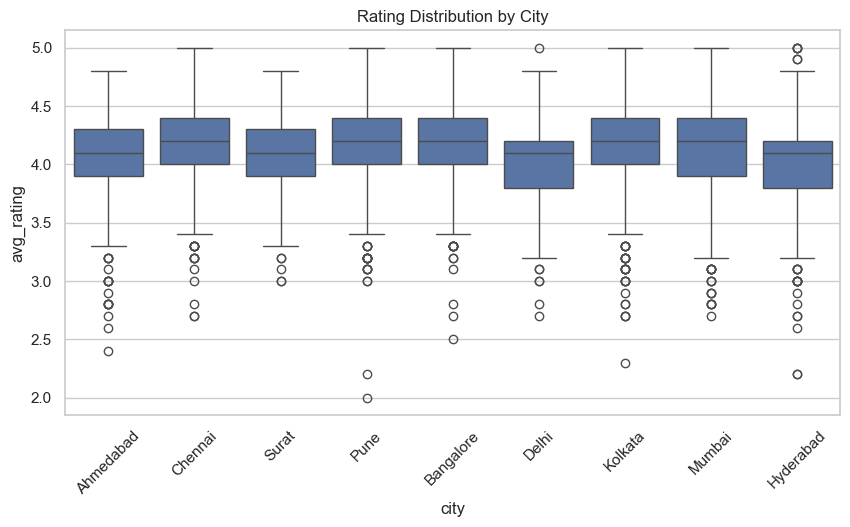

In [27]:
sns.boxplot(data=df, x="city", y="avg_rating")
plt.xticks(rotation=45)
plt.title("Rating Distribution by City")
plt.savefig(r"F:\data analyst\Project 1\fig_rating_by_city.png", dpi=150, bbox_inches="tight")
plt.show()